In [1]:
import re, json, base64, struct, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

In [2]:
SEQID_TO_SR = {
    1:  "1S",  2:  "1R",
    3:  "2S",
    4:  "3R",  5:  "3S",
    6:  "4R",  7:  "4S",
    8:  "5R",  9:  "5S",
    10: "6R",  11: "6S",
    12: "7R",  13: "7S",
    14: "8R",  15: "8S",
}

In [3]:
def parse_wakhan_html(path):
    with open(path, "r") as f:
        content = f.read()
    match = re.search(r'Plotly\.newPlot\(\s*"[^"]+",\s*(\[.*?\]),\s*\{', content, re.DOTALL)
    if not match:
        raise ValueError(f"No Plotly.newPlot found in {path}")
    trace = json.loads(match.group(1))[0]

    def decode_f8(s):
        raw = base64.b64decode(s.replace("\\u002f", "/"))
        return np.array(struct.unpack(f"{len(raw)//8}d", raw))

    x = decode_f8(trace["x"]["bdata"])  # ploidy
    y = decode_f8(trace["y"]["bdata"])  # purity
    z_raw = base64.b64decode(trace["z"]["bdata"].replace("\\u002f", "/"))
    z = np.array(struct.unpack(f"{len(z_raw)//8}d", z_raw)).reshape(len(y), len(x))

    idx = np.unravel_index(np.argmin(z), z.shape)
    return {
        "best_ploidy":  x[idx[1]],
        "best_purity":  y[idx[0]],
        "best_pval":    z[idx],
        "ploidy_range": (x.min(), x.max()),
        "purity_range": (y.min(), y.max()),
        "edge_hit": idx[1] == 0 or idx[1] == len(x)-1 or idx[0] == 0 or idx[0] == len(y)-1,
    }

In [4]:
HTML_DIR = "/path/to/data/Wakhan"
LABEL_MAP = {}  # fill in later if you want short labels

records = []
for path in sorted(glob.glob(f"{HTML_DIR}/**/*_heatmap_ploidy_purity.html", recursive=True)):
    sample_id = Path(path).parent.name
    label = LABEL_MAP.get(sample_id, sample_id)
    res = parse_wakhan_html(path)
    records.append({"sample": label, **res})
    print(f"{label:50s}  ploidy={res['best_ploidy']:.3f}  purity={res['best_purity']:.3f}  p={res['best_pval']:.4f}{'  ⚠ edge' if res['edge_hit'] else ''}")

df = pd.DataFrame(records)
df

ONTWGS9-1-238701-NP01                               ploidy=1.541  purity=0.304  p=0.3073  ⚠ edge
ONTWGS9-10-240188-NP01                              ploidy=1.536  purity=0.514  p=0.2633  ⚠ edge
ONTWGS9-11-240189-NP01                              ploidy=1.522  purity=0.553  p=0.2733  ⚠ edge
ONTWGS9-12-240190-NP01                              ploidy=1.520  purity=0.518  p=0.3357  ⚠ edge
ONTWGS9-13-240191-NP01                              ploidy=1.520  purity=0.560  p=0.3304  ⚠ edge
ONTWGS9-14-240192-NP01                              ploidy=1.548  purity=0.347  p=0.3313  ⚠ edge
ONTWGS9-15-240193-NP01                              ploidy=1.518  purity=0.376  p=0.3463  ⚠ edge
ONTWGS9-2-238702-NP01                               ploidy=1.868  purity=0.301  p=0.3735  ⚠ edge
ONTWGS9-3-238703-NP01                               ploidy=1.536  purity=0.646  p=0.1850  ⚠ edge
ONTWGS9-4-240182-NP01                               ploidy=1.600  purity=0.517  p=0.2915  ⚠ edge
ONTWGS9-5-240183-NP01         

,sample,best_ploidy,best_purity,best_pval,ploidy_range,purity_range,edge_hit
0,ONTWGS9-1-238701-NP01,1.5410,0.3044,0.307342,"(1.5007, 3.6756)","(0.3044, 0.9894)",True
1,ONTWGS9-10-240188-NP01,1.5362,0.5137,0.263303,"(1.5362, 1.9504)","(0.5137, 0.9941)",True
2,ONTWGS9-11-240189-NP01,1.5220,0.5528,0.273253,"(1.522, 1.9484)","(0.5528, 0.9936)",True
3,ONTWGS9-12-240190-NP01,1.5205,0.5176,0.335662,"(1.5205, 1.7548)","(0.5176, 0.994)",True
4,ONTWGS9-13-240191-NP01,1.5201,0.5596,0.330433,"(1.5201, 1.7819)","(0.5596, 0.9942)",True
5,ONTWGS9-14-240192-NP01,1.5484,0.3467,0.331285,"(1.5305, 3.1546)","(0.3467, 0.9892)",True
6,ONTWGS9-15-240193-NP01,1.5185,0.3755,0.346321,"(1.5185, 2.8559)","(0.3755, 0.9897)",True
7,ONTWGS9-2-238702-NP01,1.8678,0.3007,0.373506,"(1.8678, 3.8736)","(0.3007, 0.9873)",True
8,ONTWGS9-3-238703-NP01,1.5360,0.6460,0.184972,"(1.536, 1.9668)","(0.646, 0.9955)",True
9,ONTWGS9-4-240182-NP01,1.6001,0.5175,0.291487,"(1.6001, 1.9741)","(0.5175, 0.9921)",True


In [5]:
patient_pairs = defaultdict(dict)
for seqid, sr in SEQID_TO_SR.items():
    patient = int(sr[:-1])
    status = sr[-1]
    patient_pairs[patient][status] = seqid
patient_pairs = {p: v for p, v in patient_pairs.items() if "S" in v and "R" in v}

# build seqid -> label map
seqid_to_label = {}
for patient, v in patient_pairs.items():
    for status, seqid in v.items():
        seqid_to_label[seqid] = f"P{patient}{status}"

# map parsed records: extract seqid from directory name ONTWGS9-<seqid>-XXXXXX-NP01
import re
seqid_to_result = {}
for row in records:
    m = re.match(r"ONTWGS9-(\d+)-", row["sample"])
    if m:
        seqid = int(m.group(1))
        seqid_to_result[seqid] = row

# build plot-ready dataframe
plot_rows = []
for patient, v in sorted(patient_pairs.items()):
    for status in ["R", "S"]:
        seqid = v.get(status)
        if seqid is None:
            continue
        label = seqid_to_label[seqid]
        if seqid not in seqid_to_result:
            print(f"  missing: {label} (seqid {seqid})")
            continue
        res = seqid_to_result[seqid]
        plot_rows.append({
            "patient": patient,
            "status": status,
            "label": label,
            "ploidy": res["best_ploidy"],
            "purity": res["best_purity"],
            "pval":   res["best_pval"],
            "edge_hit": res["edge_hit"],
        })

pdf = pd.DataFrame(plot_rows)
pdf

,patient,status,label,ploidy,purity,pval,edge_hit
0,1,R,P1R,1.8678,0.3007,0.373506,True
1,1,S,P1S,1.5410,0.3044,0.307342,True
2,3,R,P3R,1.6001,0.5175,0.291487,True
3,3,S,P3S,1.5112,0.5689,0.280243,True
4,4,R,P4R,1.5617,0.5346,0.234526,True
5,4,S,P4S,1.5707,0.5400,0.297627,True
6,5,R,P5R,1.5071,0.5272,0.270630,True
7,5,S,P5S,1.5099,0.5480,0.277812,True
8,6,R,P6R,1.5362,0.5137,0.263303,True
9,6,S,P6S,1.5220,0.5528,0.273253,True


In [6]:
print("pdf shape:", pdf.shape)
print("pdf columns:", pdf.columns.tolist())
print("records count:", len(records))
print("seqid_to_result keys:", list(seqid_to_result.keys()))
print("patient_pairs:", patient_pairs)

pdf shape: (14, 7)
pdf columns: ['patient', 'status', 'label', 'ploidy', 'purity', 'pval', 'edge_hit']
records count: 15
seqid_to_result keys: [1, 10, 11, 12, 13, 14, 15, 2, 3, 4, 5, 6, 7, 8, 9]
patient_pairs: {1: {'S': 1, 'R': 2}, 3: {'R': 4, 'S': 5}, 4: {'R': 6, 'S': 7}, 5: {'R': 8, 'S': 9}, 6: {'R': 10, 'S': 11}, 7: {'R': 12, 'S': 13}, 8: {'R': 14, 'S': 15}}


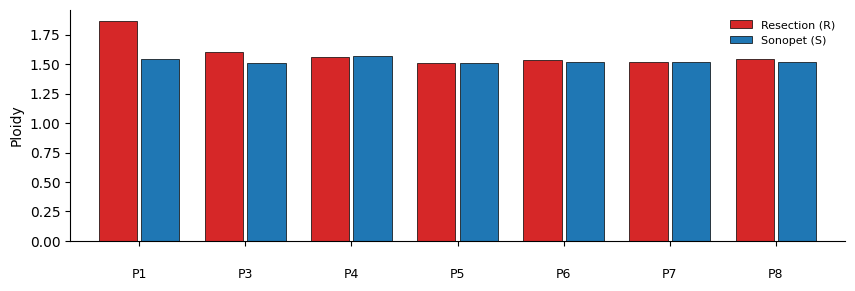

Saved: /path/to/data/Wakhan/wakhan_ploidy.pdf


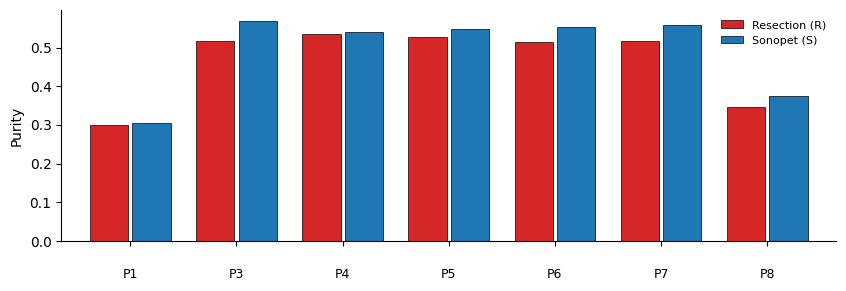

Saved: /path/to/data/Wakhan/wakhan_purity.pdf


In [8]:
patients = sorted(pdf["patient"].unique())
x = np.arange(len(patients))
bar_width = 0.4

colors    = {"R": "tab:red", "S": "tab:blue"}

for metric, ylabel, fname in [
    ("ploidy", "Ploidy", "wakhan_ploidy.pdf"),
    ("purity", "Purity", "wakhan_purity.pdf"),
]:
    fig, ax = plt.subplots(figsize=(10, 3), facecolor="white")
    ax.set_facecolor("white")
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

    for j, status in enumerate(["R", "S"]):
        for i, patient in enumerate(patients):
            row = pdf[(pdf["patient"] == patient) & (pdf["status"] == status)]
            if row.empty:
                continue
            xpos = i + (j - 0.5) * bar_width
            val = row[metric].values[0]
            pval = row["pval"].values[0]

            ax.bar(xpos, val, width=bar_width * 0.9,
                   color=colors[status], edgecolor="black", linewidth=0.5, zorder=2)
            # ax.annotate(f'{pval:.3f}',
            #             xy=(xpos, 0), xycoords=("data", "axes fraction"),
            #             xytext=(xpos, -0.1), textcoords=("data", "axes fraction"),
            #             fontsize=8, ha="center", color=colors[status],
            #             annotation_clip=False)
            
    # label the p-value row
    # ax.annotate("best p-value:", xy=(0, 0), xycoords=("axes fraction", "axes fraction"),
    #             xytext=(-0.01, -0.1), textcoords=("axes fraction", "axes fraction"),
    #             fontsize=8, ha="right", color="black", annotation_clip=False)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"P{p}" for p in patients], fontsize=9)
    ax.tick_params(axis="x", pad=16)
    ax.margins(x=0.04)

    legend_elements = [
        plt.Rectangle((0,0), 1, 1, facecolor=colors["R"], edgecolor="black", linewidth=0.5, label="Resection (R)"),
        plt.Rectangle((0,0), 1, 1, facecolor=colors["S"], edgecolor="black", linewidth=0.5, label="Sonopet (S)"),
    ]
    ax.legend(handles=legend_elements, fontsize=8, frameon=False, loc="upper right")

    save_path = f"/path/to/data/Wakhan/{fname}"
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {save_path}")